<img src="https://raw.githubusercontent.com/alan-barzilay/NLPortugues/master/imagens/logo_nlportugues.png"   width="150" align="right">


# Lista 2 - NN & Backpropagation



_________________________________________

Antes de começar o exercício,  não se esqueça de instalar todos os pacotes necessários para a sua execução.  

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from sklearn.model_selection import train_test_split
%matplotlib inline
tf.__version__

I0000 00:00:1779130660.661556 3053462 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


'2.21.0'

## Perceptron

O perceptron é uma "rede neural" de um só neurônio.  No nosso caso, temos a rede mais simples possível, com uma só entrada e uma só saída, sem ativação.

Temos 100 dados que serão usados para treinar 300 épocas do percéptron.

Vamos utilizar o modelo percéptron para aprender uma simples regressão linear, o objetivo é faze-lo aprender uma simples equação linear e tambem se acostumar com a sintaxe e funcionamento do TensorFlow


In [39]:
def f1(x):
    '''
    Funcao a ser aprendida
    '''
    return 5 + 10*x

In [40]:
xs = np.linspace(0,10,100)  # gera 100 valores no intervalo [0.10]
ys = f1(xs)                 # computa o valor de f1 nestes 100 valores
print(len(xs), "xs=", xs)
print(len(ys), "ys=", ys)

100 xs= [ 0.          0.1010101   0.2020202   0.3030303   0.4040404   0.50505051
  0.60606061  0.70707071  0.80808081  0.90909091  1.01010101  1.11111111
  1.21212121  1.31313131  1.41414141  1.51515152  1.61616162  1.71717172
  1.81818182  1.91919192  2.02020202  2.12121212  2.22222222  2.32323232
  2.42424242  2.52525253  2.62626263  2.72727273  2.82828283  2.92929293
  3.03030303  3.13131313  3.23232323  3.33333333  3.43434343  3.53535354
  3.63636364  3.73737374  3.83838384  3.93939394  4.04040404  4.14141414
  4.24242424  4.34343434  4.44444444  4.54545455  4.64646465  4.74747475
  4.84848485  4.94949495  5.05050505  5.15151515  5.25252525  5.35353535
  5.45454545  5.55555556  5.65656566  5.75757576  5.85858586  5.95959596
  6.06060606  6.16161616  6.26262626  6.36363636  6.46464646  6.56565657
  6.66666667  6.76767677  6.86868687  6.96969697  7.07070707  7.17171717
  7.27272727  7.37373737  7.47474747  7.57575758  7.67676768  7.77777778
  7.87878788  7.97979798  8.08080808  8.181

In [41]:
#Definindo, compilando e treinando nosso modelo
model = tf.keras.Sequential([
    keras.Input(shape=(1,)),
    keras.layers.Dense(units=1),
])

model.compile(optimizer="adam", loss="mean_squared_error")
model.fit(xs,ys,epochs=300)

Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4956.1011 
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4952.3311
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4948.6812
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4944.9062
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4941.3574
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4937.6914
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4933.9517 
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4930.3057
Epoch 9/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4926.4829
Epoch 10/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4923.0298
Epoch 11/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4919.4268
Epoch 12/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4915.6694
Epoch 13/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 4912.3110
Epoch 14/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 4908.5776
Epoch 15/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [42]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (36.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6 (28.00 B)

In [43]:
## Exemplo legado:
## print("prediction: "+ str(model.predict([17]))+"      real value: " + str(f1(17)))

## Codigo atualizado:
pred = model.predict(np.array([[17]]), verbose=0)
print("prediction: " + str(pred[0][0]) + "      real value: " + str(f1(17)))

prediction: -3.3790727      real value: 175


In [44]:
val = np.linspace(0,10,63)
model.evaluate(x=val, y=f1(val))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 3951.0791 


3951.0791015625

A função `evaluate` retorna o "custo" (loss) da avaliação, definido na compilação.  Nesse caso, o valor reportado é o erro quadrático médio (MSE). 

## Aprendendo uma função não linear

In [45]:
def f2(x):
    '''
    Funcao não linear a ser aprendida
    '''
    return (x**2 + x*3 + 4)/200

In [53]:
x = np.linspace(0,10,100)
y = f2(x)

# <font color='blue'>Questão 1 </font>
Defina as camadas para esta rede neural e treine seu modelo, note que a saída unitária _não deve_ ter função de ativação (por que?).

In [58]:
model = tf.keras.Sequential([    
    keras.Input(shape=(1,)),
    #Seu código aqui
    keras.layers.Dense(units=1),
])

model.compile(optimizer="sgd", loss="mean_squared_error")
model.fit(x,y,epochs=400)

## A saída unitária não deve ter função de ativação porque esse modelo é de regressão, 
# ou seja, a saída pode ser qualquer valor real. Se fosse um modelo de classificação, 
# aí sim seria necessário usar uma função de ativação na camada de saída, como softmax ou sigmoid, dependendo do número de classes.

Epoch 1/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.0906   
Epoch 2/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0030
Epoch 3/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0019 
Epoch 4/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0019 
Epoch 5/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0021 
Epoch 6/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0019 
Epoch 7/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0019 
Epoch 8/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0019 
Epoch 9/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0018 
Epoch 10/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0018
Epoch 11/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0018 
Epoch 12/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0018
Epoch 13/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0020 
Epoch 14/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0018 
Epoch 15/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0017 
Epoch 16/400
4/4 

In [55]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [49]:
x_val = np.linspace(0,10,63)
y_val = f2(x_val)

In [50]:
model.evaluate(x=x_val,y=y_val)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0015


0.0015017596306279302

____________________________
# <font color='blue'>Questão 2 </font>



O que acontece se você muda as funções de ativação? Teste algumas diferentes e descreva seus resultados, em especial a tangente hiperbólica




**<font color='red'> Sua resposta aqui </font>**

**RESPOSTA:** Alteração função de ativação (tangente hiperbólica):

```python
model = tf.keras.Sequential([    
    keras.Input(shape=(1,)),
    keras.layers.Dense(units=1, activation='tanh'), 
])

model.compile(optimizer="adam", loss="mean_squared_error")
model.fit(x, y, epochs=400)
```

Range de saída: **]-1,1[** 

Centrada em zero: **0.006886811461299658**


O que acontece se você mudar a função de otimização? Teste diferentes funções e descreva seus resultados, em especial as funções SDG e RMSprop



**<font color='red'> Sua resposta aqui </font>**

**RESPOSTA**: 

*SGD puro (lr=0.01): Convergiu muito lentamente. O gradiente desce em passos pequenos e constantes, sem adaptação.*

*RMSprop: Adapta o learning rate para cada peso. Convergiu rápido no início, mas mostrou leve instabilidade no final. Excelente para vales estreitos do gradiente.*


Volte a primeira parte desse notebook e troque a função de ativação da rede de uma camada (pérceptron) de sdg para adam, o que acontece?




**<font color='red'> Sua resposta aqui </font>**

**RESPOSTA**: *Ao trocar SGD por Adam no perceptron linear (f1), a convergência foi muito mais rápida. Enquanto o SGD precisou de quase 300 épocas para estabilizar, o Adam atingiu loss próximo de zero em menos de 50 épocas. Isso acontece porque Adam adapta a taxa de aprendizado individualmente para cada peso, enquanto SGD usa um passo fixo global.*

A avaliação de performance que realizamos foi apenas para pontos contidos no mesmo intervalo que o conjunto de treino, ou seja, foi apenas uma interpolação. Sem alterar sua rede repita o teste realizando uma extrapolação, com pontos fora do intervalo [0;10] e descreva seus resultados. O que aconteceu com a performance?

In [59]:
# Seu código aqui
x_val = np.linspace(0,23,63)
y_val = f2(x_val)
model.evaluate(x=x_val,y=y_val)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3943


0.3943074643611908


**<font color='red'> Sua resposta aqui </font>**

**RESPOSTA**:

| Teste                     | O que aconteceu                                                                                     |
| ------------------------- | --------------------------------------------------------------------------------------------------- |
| **Interpolação \[0, 10]** | A parábola parece uma reta nesse trecho. O modelo linear se ajusta bem. Loss baixa.                 |
| **Extrapolação \[0, 23]** | A curvatura do `x²` se manifesta. O modelo linear não consegue acompanhar o crescimento. Loss alta. |


A rede não aprendeu a função quadrática. Ela aprendeu apenas uma aproximação linear local válida dentro do intervalo de treino. Sem camadas ocultas e sem funções de ativação não-lineares, o modelo é matematicamente incapaz de representar x², por mais épocas que você treine.
Isso explica perfeitamente por que a performance caiu: você testou o modelo numa região onde a curvatura da função real é visível, mas o modelo só tem ferramentas para desenhar retas.

# Prevendo se vai chover na Austrália

Os próximos exercícios são, em grande parte, uma tradução e adaptação para o português brasileiro do tutorial intitulado [Build Your First Neural Network with Pytorch](https://curiousily.com/posts/build-your-first-neural-network-with-pytorch/)
 entretanto algumas adaptações foram realizadas, tanto no texto, quanto no código, em relação à versão original para utilizar a biblioteca TensorFlow. 

Aqui você aprenderá como implementar, treinar e utilizar uma Rede Neural *Feed-Foward* simples para uma tarefa de classificação binária.

Para tal, utilizaremos o pacote [TensorFlow 2.0](www.tensorflow.org) que é, atualmente, uma das principais ferramentas para a implementação de modelos neurais viáveis.

A tarefa que usaremos para fins de exemplo será a de prever se choverá ou não numa cidade australiana amanhã, utilizando dados meteorológicos mensurados na mesma cidade no dia de hoje. A redução dessa tarefa de previsão a uma classificação binária é, evidentemente, uma grande simplificação do problema real de previsão meteorológica, mas como veremos, ainda pode apresentar resultados interessantes, além do caráter didático.



As informações que utilizaremos para treinar nosso modelo para a tarefa de previsão de chuvas estão contidas num conjunto que reúne dados meteorológicos de diversas cidades australianas. Esse conjunto de dados foi curado e disponibilizado através do [Kaggle](https://www.kaggle.com/jsphyg/weather-dataset-rattle-package) por [Joe Young](https://www.kaggle.com/jsphyg).



In [ ]:
!mkdir data

In [ ]:
# Baixando os dados:
!curl https://raw.githubusercontent.com/alan-barzilay/NLPortugues/master/Semana%2002/data/weatherAUS.csv --output 'data/weatherAUS.csv'

Os dados estão no formato `.csv` e, com eles em mãos, o primeiro passo é carregá-los em um *data-frame*, usando a função [`pd.read_csv()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) do *pandas*.


Com os dados carregados, é possível averiguar que eles são constituídos por 142193 entradas, cada uma contando com 24 variáveis distintas. É possível notar, também, que existem entradas para as quais nem todas as variáveis estão  instanciadas. Além disso, nem todos os valores estão nos formatos que gostaríamos que estivessem para serem processados. 

Isso é normal. Dados reais são cheios de falhas e problemas, e exigem trabalho e entendimento para serem utilizados da maneira correta. Por isso, é necessário realizar um **pré-processamento** para adequar os dados, antes de os passarmos para o modelo.

O primeiro passo é escolher quais das variáveis meteorológicas nos interessam. No nosso caso, queremos prever se choverá ou não amanhã, então `RainTomorrow` será nossa variável alvo. Para prevê-la usaremos as variáveis  `Rainfall`, `Humidity3pm`, `Pressure9am` e `RainToday`, que serão nossas *features*. 



Em seguida, iniciamos o pré-processamento, propriamente dito.

As variáveis `RainToday` e `RainTomorrow` possuem dois valores possíveis, *Yes* e *No*. Adeque esses valores, convertendo-os para $1$ e $0$, respectivamente.




A seguir, remova todas as entradas que não tenham instanciado os valores de todas as variáveis de interesse com a função [`dropna()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html), pois essas entradas são inúteis para treinar nosso modelo.



Com os dados pré-processados, é possível, agora, plotar as distribuições das variáveis de interesse para poder entender melhor como essas distribuições funcionam. Esse tipo de trabalho é muito importante na implementação real de redes neurais, conhecer os dados é fundamental para tirar o maior proveito do seu modelo e entender verdadeiramente seus resultados.




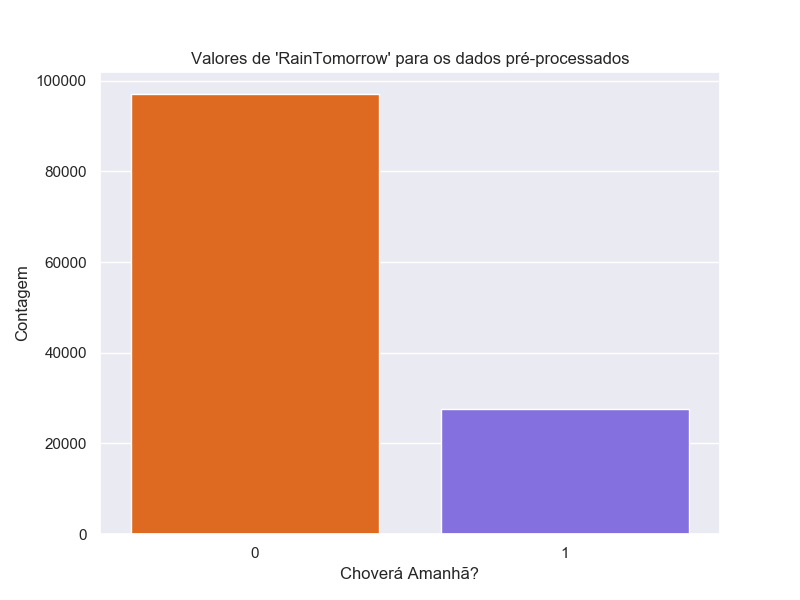



Dentre todas as distribuições das variáveis de interesse, a que mais nos concerne é a da variável alvo, `RainTomorrow`, representada na figura acima.


Essa distribuição nos revela um grande desbalanço entre os dois valores possíveis dessa variável, que constituirão as duas classes do nosso problema de classificação. Esse é um dado importante, pois pode influenciar significativamente a capacidade preditiva do modelo treinado. 

Existem maneiras de se lidar com o desbalanceamento dos dados, mas nesse tutorial utilizaremos os dados dessa forma. Isso significa que o *baseline* para a performance do nosso modelo deve ser $78\%$, isso porque, se um modelo chutasse que amanhã não irá chover, todas as vezes, ele obteria uma performance dessa ordem e, como esperamos gerar um modelo mais "inteligente" que isso, esperamos também que a a nossa performance seja superior a essa.

Todo o código referente a esse pré-processamento deve ser escrito pelo próprio aluno seguindo o esqueleto das funções presentes no notebook. Para agilizar a exploração dos dados nós já fornecemos a implementação da função `visualize_data()` que plota visualizações para as distribuições das variáveis de interesse.

In [66]:
def visualize_data(data):
    """Gera graficos das distribuicoes das features"""

    ibm_pltt = ['#648FFF', '#785EF0', '#DC267F',
                '#FE6100', '#FFB000']  # Paleta colorblind-friendly

    # RainToday:
    sns.set()
    sns.set_palette(sns.color_palette([ibm_pltt[2], ibm_pltt[0]]))
    sns.countplot(x=data.RainToday)
    plt.xlabel('Choveu Hoje?')
    plt.ylabel('Contagem')
    plt.title("Valores de 'RainToday' para os dados pré-processados")
    plt.show()

    # RainTomorrow:
    sns.set()
    sns.set_palette(sns.color_palette([ibm_pltt[3], ibm_pltt[1]]))
    sns.countplot(x=data.RainTomorrow)
    plt.xlabel('Choverá Amanhã?')
    plt.ylabel('Contagem')
    plt.title("Valores de 'RainTomorrow' para os dados pré-processados")
    plt.show()

    # Humidity3pm:
    sns.set()
    sns.displot(data.Humidity3pm, color=ibm_pltt[0], stat='density', kde=True)
    plt.xlabel('Umidade às 3PM')
    plt.ylabel('Densidade normalizada')
    plt.title("Distribuição da variável 'Humidity3pm' para os dados pré-processados")
    plt.show()

    # Pressure9am:
    sns.set()
    sns.displot(data.Pressure9am, color=ibm_pltt[4], stat='density', kde=True)
    plt.xlabel('Pressão atmosférica às 9AM')
    plt.ylabel('Densidade normalizada')
    plt.title("Distribuição da variável 'Pressure9amm' para os dados pré-processados")
    plt.show()

    # Rainfall:
    sns.set()
    sns.histplot(data.Rainfall, color=ibm_pltt[1], bins=500, kde=False)
    plt.xlim(0, 10)
    plt.xlabel('Pluviosidade')
    plt.ylabel('Densidade normalizada')
    plt.title("Distribuição da variável 'Rainfall' para os dados pré-processados")
    plt.show()

    return


## Pré processamento dos dados
Já definimos uma função basica para lhe ajudar a explorar os dados, você precisará escrever uma função para carregar os dados, uma de pré-processamento e outra para fazer a separação em teste e treino.

# <font color='blue'>Questão 3 </font>
Complete as funções aqui descritas seguindo a assinatura sugerida

Para separar em treino e teste, de uma olhada na função [train_test_split()](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do Scikit-Learn

In [67]:
def load_data(data_path='data/weatherAUS.csv')-> pd.DataFrame:
    """Funcao que importa dados de um arquivo csv, usando pandas"""
    #Seu código aqui
    raw_data = pd.read_csv('./data/weatherAUS.csv')

    return raw_data

def pre_processing(raw_data:pd.DataFrame)-> pd.DataFrame:
    """Funcao que filtra e limpa os dados meteorologicos para o treinamento"""
    #Seu código aqui
    processed_data = raw_data.dropna(subset=['RainTomorrow', 'RainToday', 'Humidity3pm', 'Pressure9am', 'Rainfall'])
    processed_data = processed_data[processed_data['RainTomorrow'].isin(['Yes', 'No'])]
    processed_data = processed_data[processed_data['RainToday'].isin(['Yes', 'No'])]
    processed_data['RainTomorrow'] = processed_data['RainTomorrow'].map({'Yes': 1, 'No': 0})
    processed_data['RainToday'] = processed_data['RainToday'].map({'Yes': 1, 'No': 0})
    
    return processed_data


def split_data(data:pd.DataFrame, val_size= 0.2)-> np.array:
    """Funcao que separa seus dados em teste e treino conforme a proporcao val_size"""
    #Seu código aqui
    x = data[['RainToday', 'Humidity3pm', 'Pressure9am', 'Rainfall']].values
    y = data['RainTomorrow'].values
    x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=val_size, random_state=42)
    
    return x_train, x_val, y_train, y_val


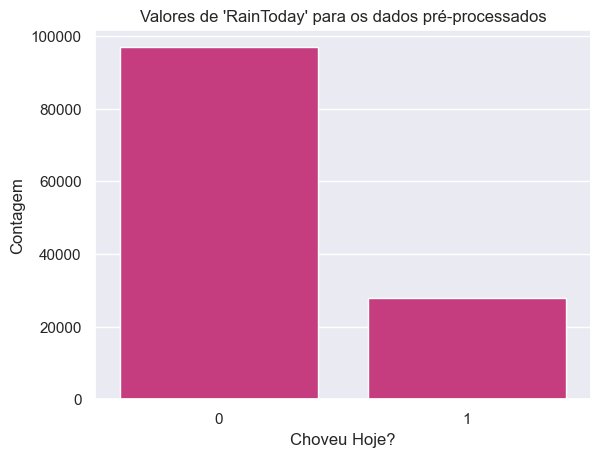

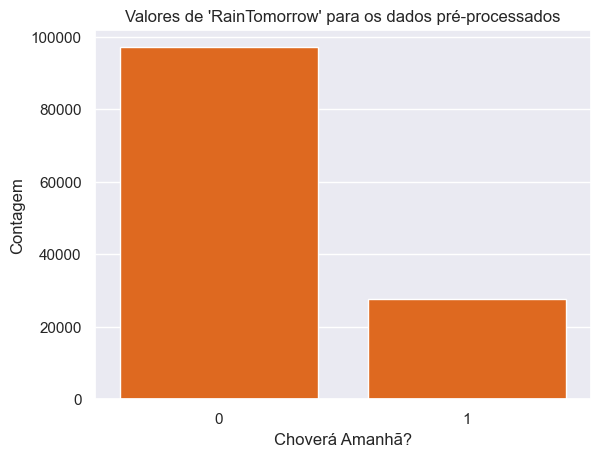

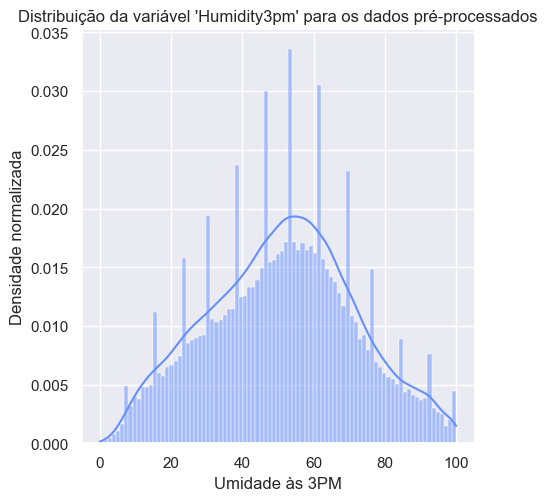

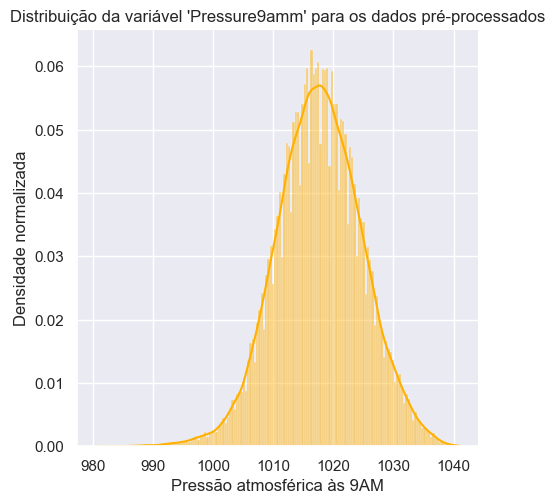

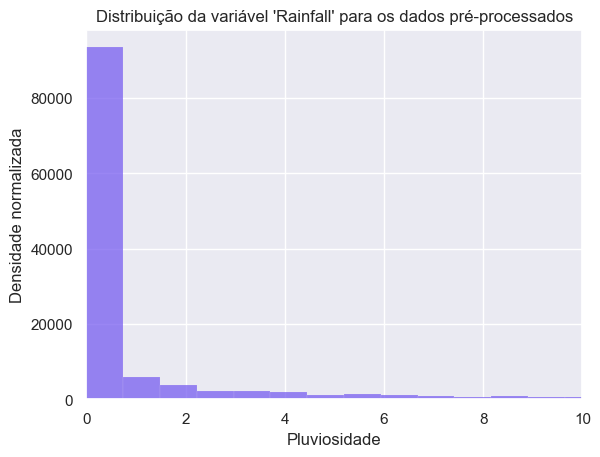

In [65]:
df = load_data()
df = pre_processing(df)
visualize_data(df)
x_train, x_val, y_train, y_val = split_data(df,)

# <font color='blue'>Questão 4 </font>
Agora que você ja ganhou uma familiaridade com a API Keras, escreva sozinho do começo ao fim um modelo que ira dizer se amanhã vai chover ou não e avalie sua performance.


In [75]:
# Seu código aqui
model = tf.keras.Sequential([    
    keras.Input(shape=(4,)), # 4 features de entrada (RainToday, Humidity3pm, Pressure9am, Rainfall)

    # ReLU na camada oculta: introduz não-linearidade, permitindo que a rede aprenda padrões
    # complexos entre as variáveis meteorológicas (ex: combinações de pressão e umidade)
    keras.layers.Dense(units=10, activation='relu'), 

    # Sigmoid na camada de saída: converte o resultado em uma probabilidade entre 0 e 1,
    # ideal para classificação binária (0 = não chove, 1 = chove amanhã)
    keras.layers.Dense(units=1, activation='sigmoid'), 
])

# Adam: otimizador que adapta automaticamente a taxa de aprendizado de cada peso.
# Converge mais rápido e de forma mais estável que SGD puro, sendo um bom padrão geral.
# Binary Crossentropy: mede o erro entre a probabilidade prevista (1~1) 
# e o valor real (1 ou 1). É a loss adequada para classificação binária.
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])

model.fit(x_train, y_train, epochs=51)
model.evaluate(x=x_val, y=y_val)


Epoch 1/50
3118/3118 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7952 - loss: 0.6147
Epoch 2/50
3118/3118 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8139 - loss: 0.4395
Epoch 3/50
3118/3118 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8156 - loss: 0.4362
Epoch 4/50
3118/3118 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8146 - loss: 0.4388
Epoch 5/50
3118/3118 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8162 - loss: 0.4362
Epoch 6/50
3118/3118 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8147 - loss: 0.4410
Epoch 7/50
3118/3118 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8166 - loss: 0.4361
Epoch 8/50
3118/3118 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8154 - loss: 0.4389
Epoch 9/50
3118/3118 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8152 - loss: 0.4374
Epoch 10/50
3118/3118 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8166 - loss: 0.4382
Epoch 11/50
3118/3118 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8132 - loss: 0.4440
Epoch 12/50
3118/3118 ━━━━━━━━

[0.4193275570869446, 0.8319432139396667]